<h1 style: text-align:center;>Family Income & Expenditure</h1>


## How Household Assets Reflect Wealth Stability and Non-Food Spending
Student: Jade Carlo Redota and Joanne Juanane
Course: ITPS308  
Dataset: Family Income and Expenditure.csv

# Description
This analysis studies how household assets relate to spending behavior, especially non-food expenditure.  
The goal is to understand whether asset ownership can show differences in living conditions and predict household spending patterns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import warnings

sns.set(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10,5)

<h2>Load dataset </h2>

In [2]:
df = pd.read_csv("Datasets/Family Income and Expenditure.csv")

In [3]:
df.columns = [c.strip() for c in df.columns]

In [4]:
print("Loaded dataset shape:", df.shape)

Loaded dataset shape: (41544, 60)


In [5]:
for i, col in enumerate(df.columns, start=1):
    print(i, col)


1 Total Household Income
2 Region
3 Total Food Expenditure
4 Main Source of Income
5 Agricultural Household indicator
6 Bread and Cereals Expenditure
7 Total Rice Expenditure
8 Meat Expenditure
9 Total Fish and  marine products Expenditure
10 Fruit Expenditure
11 Vegetables Expenditure
12 Restaurant and hotels Expenditure
13 Alcoholic Beverages Expenditure
14 Tobacco Expenditure
15 Clothing, Footwear and Other Wear Expenditure
16 Housing and water Expenditure
17 Imputed House Rental Value
18 Medical Care Expenditure
19 Transportation Expenditure
20 Communication Expenditure
21 Education Expenditure
22 Miscellaneous Goods and Services Expenditure
23 Special Occasions Expenditure
24 Crop Farming and Gardening expenses
25 Total Income from Entrepreneurial Acitivites
26 Household Head Sex
27 Household Head Age
28 Household Head Marital Status
29 Household Head Highest Grade Completed
30 Household Head Job or Business Indicator
31 Household Head Occupation
32 Household Head Class of Worker


<h3>Remove stray spaces</h3>

In [6]:
df.columns = [c.strip() for c in df.columns]
print("Rows, cols:", df.shape)
# quick peek
display(df.head(3))

Rows, cols: (41544, 60)


,Total Household Income,Region,Total Food Expenditure,Main Source of Income,Agricultural Household indicator,Bread and Cereals Expenditure,Total Rice Expenditure,Meat Expenditure,Total Fish and marine products Expenditure,Fruit Expenditure,...,Number of Refrigerator/Freezer,Number of Washing Machine,Number of Airconditioner,"Number of Car, Jeep, Van",Number of Landline/wireless telephones,Number of Cellular phone,Number of Personal Computer,Number of Stove with Oven/Gas Range,Number of Motorized Banca,Number of Motorcycle/Tricycle
0,480332,CAR,117848,Wage/Salaries,0,42140,38300,24676,16806,3325,...,1,1,0,0,0,2,1,0,0,1
1,198235,CAR,67766,Wage/Salaries,0,17329,13008,17434,11073,2035,...,0,1,0,0,0,3,1,0,0,2
2,82785,CAR,61609,Wage/Salaries,1,34182,32001,7783,2590,1730,...,0,0,0,0,0,0,0,0,0,0


<h2>1. Data cleaning and creating required variables</h2>
<h4>Convert numeric fields</h4>

In [7]:
df['Total Household Income'] = pd.to_numeric(df['Total Household Income'], errors='coerce')
df['Total Food Expenditure'] = pd.to_numeric(df['Total Food Expenditure'], errors='coerce')


<h3>Non-food expenditure columns</h3>

In [9]:
nonfood_cols = [
    'Clothing, Footwear and Other Wear Expenditure',
    'Housing and water Expenditure',
    'Imputed House Rental Value',
    'Medical Care Expenditure',
    'Transportation Expenditure',
    'Communication Expenditure',
    'Education Expenditure',
    'Miscellaneous Goods and Services Expenditure',
    'Special Occasions Expenditure',
    'Crop Farming and Gardening expenses'
]
for c in nonfood_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df['Total_NonFood_Expenditure'] = df[nonfood_cols].sum(axis=1)

# Asset columns
asset_cols = [
    'Number of Television','Number of CD/VCD/DVD','Number of Component/Stereo set',
    'Number of Refrigerator/Freezer','Number of Washing Machine','Number of Airconditioner',
    'Number of Car, Jeep, Van','Number of Landline/wireless telephones','Number of Cellular phone',
    'Number of Personal Computer','Number of Stove with Oven/Gas Range','Number of Motorized Banca',
    'Number of Motorcycle/Tricycle'
]
for c in asset_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)

df['asset_count'] = (df[asset_cols] > 0).sum(axis=1)

scaler = StandardScaler()
df['asset_score'] = scaler.fit_transform(df[asset_cols]).mean(axis=1)

df = df.dropna(subset=['Total Household Income', 'Total_NonFood_Expenditure'])
df = df.dropna(subset=['Total Household Income', 'Total_NonFood_Expenditure'])

# PREVIEW OUTPUT
df.head()

,Total Household Income,Region,Total Food Expenditure,Main Source of Income,Agricultural Household indicator,Bread and Cereals Expenditure,Total Rice Expenditure,Meat Expenditure,Total Fish and marine products Expenditure,Fruit Expenditure,...,"Number of Car, Jeep, Van",Number of Landline/wireless telephones,Number of Cellular phone,Number of Personal Computer,Number of Stove with Oven/Gas Range,Number of Motorized Banca,Number of Motorcycle/Tricycle,Total_NonFood_Expenditure,asset_count,asset_score
0,480332,CAR,117848,Wage/Salaries,0,42140,38300,24676,16806,3325,...,0,0,2,1,0,0,1,206182,7,0.337992
1,198235,CAR,67766,Wage/Salaries,0,17329,13008,17434,11073,2035,...,0,0,3,1,0,0,2,138670,7,0.579570
2,82785,CAR,61609,Wage/Salaries,1,34182,32001,7783,2590,1730,...,0,0,0,0,0,0,0,32464,0,-0.562859
3,107589,CAR,78189,Wage/Salaries,0,34030,28659,10914,10812,690,...,0,0,1,0,0,0,0,52330,2,-0.394468
4,189322,CAR,94625,Wage/Salaries,0,34820,30167,18391,11309,1395,...,0,0,3,0,0,0,1,90137,4,-0.014733


<h2>Insight</h2>
<h4>• Data Cleaning
In this code I clean the dataset by converting important columns into numeric values, creating the Total_NonFood_Expenditure variable, and generating asset related features such as asset_count and asset_score. This makes the data ready for descriptive, diagnostic, and predictive analysis.</h4>

<h1>2. Descriptive Analysis</h1>

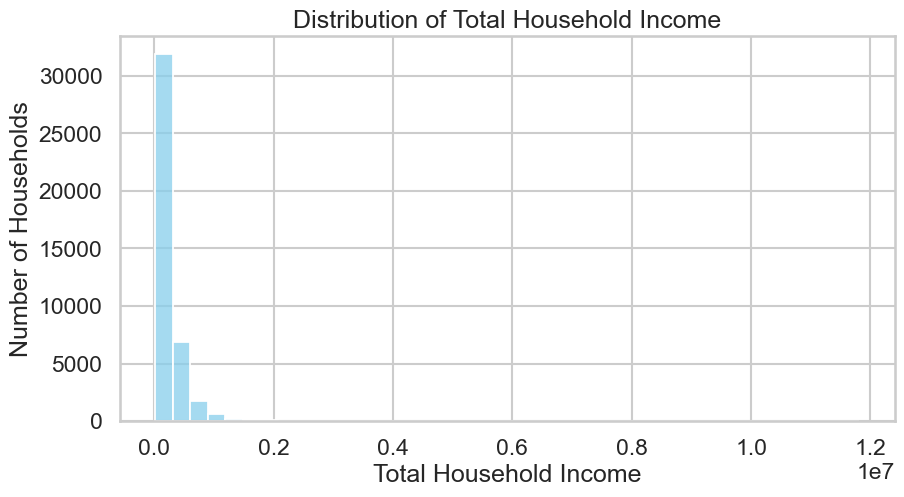

In [21]:
plt.figure(figsize=(10,5))
sns.histplot(df['Total Household Income'], bins=40, color='skyblue')
plt.title("Distribution of Total Household Income")
plt.xlabel("Total Household Income")
plt.ylabel("Number of Households")

plt.show()    


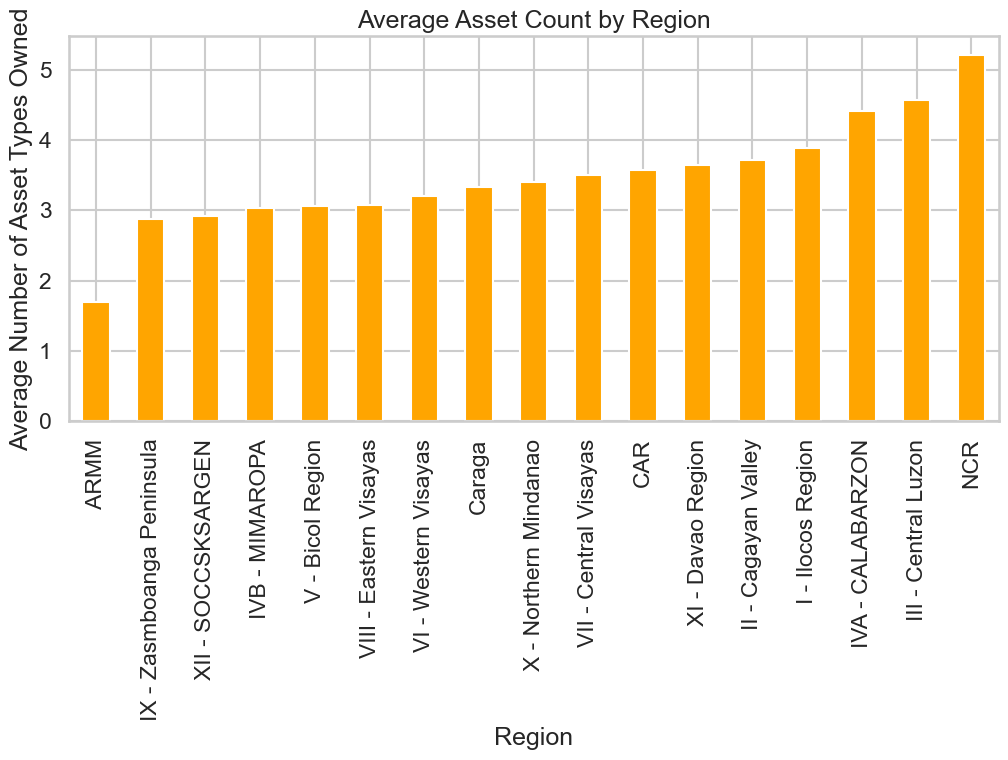

In [27]:
plt.figure(figsize=(12,5))
region_avg = df.groupby('Region')['asset_count'].mean().sort_values()
region_avg.plot(kind='bar', color='orange')
plt.title("Average Asset Count by Region")
plt.xlabel("Region")
plt.ylabel("Average Number of Asset Types Owned")

plt.show()


<h2>Descriptive Insights</h2>
<h4>• The income distribution shows that many households earn on the lower side, while only a few have very high income.</h4>
<h4>• Some regions clearly have higher asset counts, meaning wealth is not evenly distributed across locations.</h4>
<h4>• Asset ownership patterns show long-term wealth differences that income alone cannot explain.</h4>

<h1>3. Diagnostic Analysis</h1>

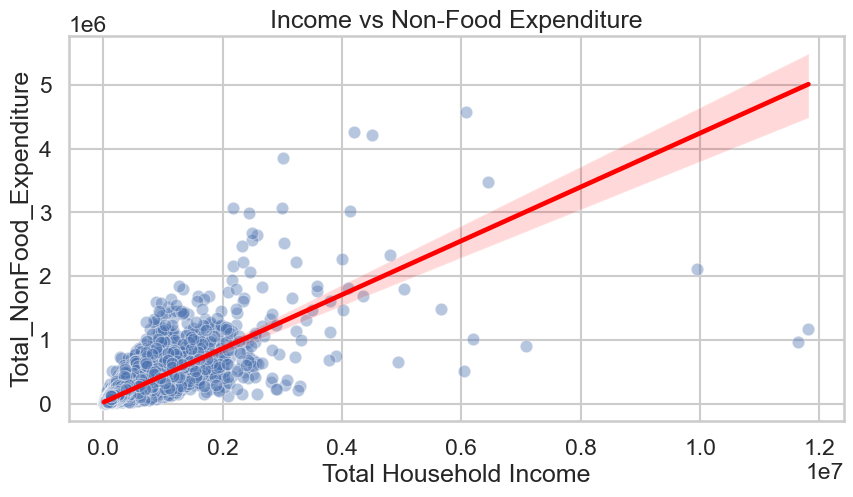

In [28]:
plt.figure(figsize=(10,5))
sns.scatterplot(
    x='Total Household Income', 
    y='Total_NonFood_Expenditure', 
    data=df, alpha=0.4
)
sns.regplot(
    x='Total Household Income', 
    y='Total_NonFood_Expenditure',
    data=df, scatter=False, color='red'
)
plt.title("Income vs Non-Food Expenditure")

plt.show()


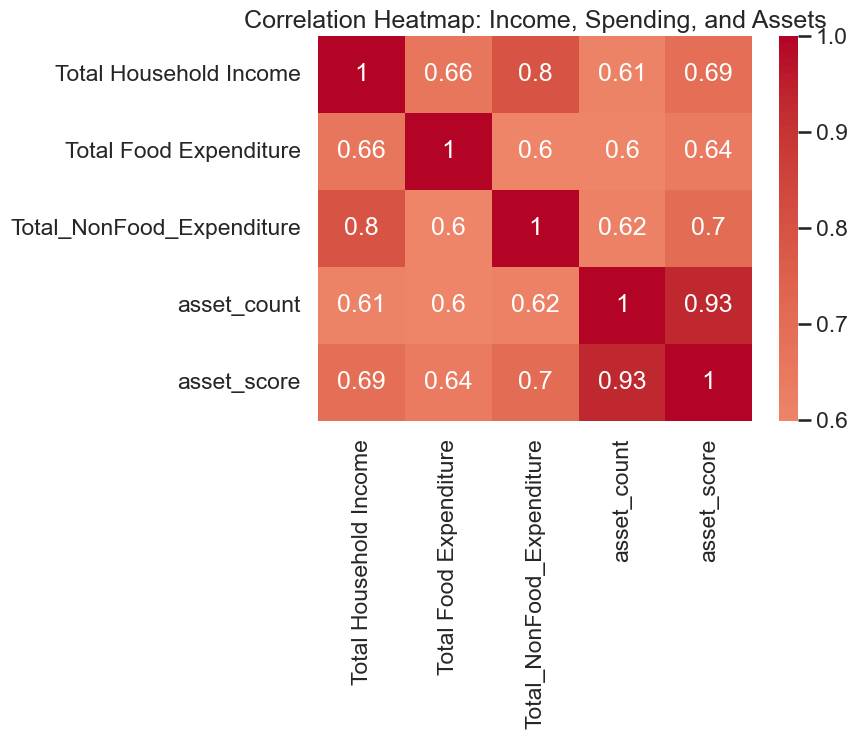

In [30]:
corr_vars = [
    'Total Household Income',
    'Total Food Expenditure',
    'Total_NonFood_Expenditure',
    'asset_count',
    'asset_score'
]

plt.figure(figsize=(7,5))
sns.heatmap(df[corr_vars].corr(), annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap: Income, Spending, and Assets")
plt.show()


<h2>Diagnostic Insights</h2>
<h4>• The scatter plot shows a positive trend, meaning higher income families usually spend more on non-food items.</h4>
<h4>• The heatmap shows strong links between income, assets, and both types of spending.</h4>
<h4>• Asset_count and asset_score are both positively related to non-food spending, showing assets help explain spending behavior.</h4>

<h1>PREDICTIVE ANALYSIS</h1>
<h4>The goal is to see whether these features can estimate how much a household spends on non-food needs.</h4>

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

features = [
    'Total Household Income',
    'asset_count',
    'asset_score',
    'Total Number of Family members'
]

X = df[features]
y = df['Total_NonFood_Expenditure']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = (mean_squared_error(y_test, y_pred))**0.5

print("R² Score:", r2)
print("RMSE:", rmse)


R² Score: 0.6891651807930578
RMSE: 82758.21745937319


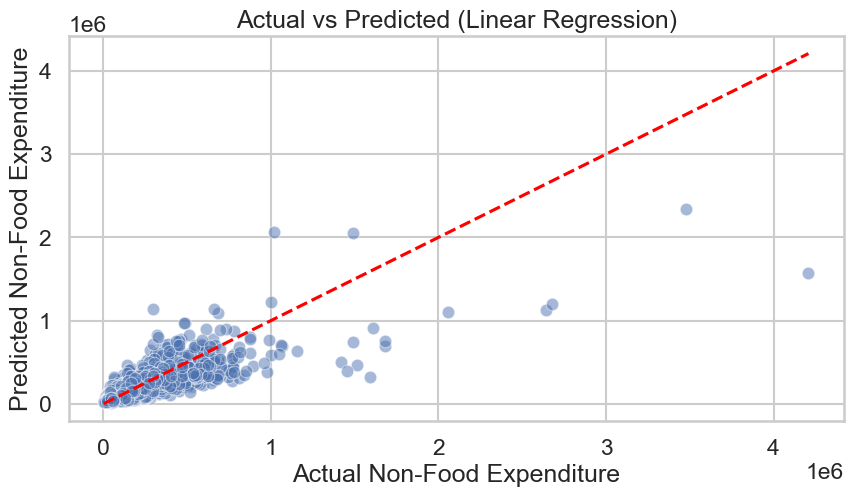

In [17]:
plt.figure(figsize=(10,5))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')
plt.xlabel("Actual Non-Food Expenditure")
plt.ylabel("Predicted Non-Food Expenditure")
plt.title("Actual vs Predicted (Linear Regression)")
plt.show()


<h2>Predictive Insights</h2>
<h4>• The model shows a decent R² score, meaning income and assets can reasonably predict non-food spending.</h4>
<h4>• The Actual vs Predicted plot shows that the predictions follow the correct trend, but some points are far from the line, meaning the model captures general patterns but not exact values.</h4>
<h4>• Asset_count and asset_score improved the prediction, showing that assets are strong indicators of household spending behavior.</h4>

<Figure size 1000x500 with 0 Axes>